## Decleration
- In this week I used GitHub Copilot and Copilot auto-complete and Claude Sonnet 5 and declared so at the corresponding code lines
- the code is strongly inspired by week36tuesday.ipynb
- the submission was done in collaboration with Johannes Schäfers, Benedikt Schneider, Ferdi Nilius and Steffen Pablo Krieg

# Exercises week 36

**FYS-STK3155/4155, fall 2026 — deadline Friday September 4 at midnight.**

The aim this week is that you own the two central results of Monday's lecture
— the statistics of the OLS estimator and the bias-variance decomposition,
Eq. (2.52) of the book — and the two resampling tools, the bootstrap and
$k$-fold cross-validation. The code you developed in the Tuesday session
(`week36tuesday.ipynb`) is meant to be reused here, and everything in this set
is directly reusable in Project 1.

Reading: Chapter 2, Sections 2.3–2.12 of the book; Hastie et al., Sections
7.1–7.5, 7.10 and 7.11.

## Exercise 1: Analytical exercises — the statistics of the OLS estimator

Assume the data are generated by the linear model of Eq. (2.37),
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$,
with independent noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ and a
fixed (non-stochastic) design matrix $\boldsymbol{X}$ of dimension $n \times p$.

**1a)** Show that the expectation value and variance of a single output are
(Eq. (2.39))

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta},
\qquad
\mathrm{Var}(y_i) = \sigma^2 .
$$

**1b)** Show that the OLS estimator is unbiased,
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}$ (Eq. (2.45)), and
derive its variance (Eq. (2.47)),

$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \sigma^2\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

*Hint:* use
$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$.

**1c)** Optional: Explain how the diagonal elements of
$\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ give a confidence interval for
the coefficient $\theta_j$ (Eq. (2.48)), and why in practice $\sigma^2$ is
replaced by
$\hat{\sigma}^2 = \|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2/(n-p)$.
Where does the $n-p$ come from? (Think of Bessel's correction, Eq. (2.28).)

**1a)**
$$
\begin{align*}
&\mathbb{E}[y_i] \\
=& \mathbb{E}[f(x_i) + \varepsilon]\\
=& \mathbb{E}[\boldsymbol{X}_{i,*}\,\boldsymbol{\theta} + \varepsilon]\\
=& \mathbb{E}[\boldsymbol{X}_{i,*}\, \boldsymbol{\theta} ]+\underbrace{\mathbb{E}[\varepsilon]}_{=0\text{, by construction}}\\
=& \int_{y\in D} P_y(y) \boldsymbol{X}_{i,*}\,\boldsymbol{\theta} dy\\
\stackrel{\text{Assuming that x is deterministic}}{=}& \boldsymbol{X}_{i,*}\,\boldsymbol{\theta} \underbrace{\int_{y\in D} P_y(y) dy}_{=1}\\
=& \boldsymbol{X}_{i,*}\,\boldsymbol{\theta}
\end{align*}
$$


$$
\begin{align*}
&\mathrm{Var}(y_i) \\
=& \mathbb{E}[y_i^2] - \underbrace{\mathbb{E}^2[y_i]}_{=(\boldsymbol{X}_{i,*}\,\boldsymbol{\theta})^2}\\
=& \mathbb{E}[(f(x_i) + \varepsilon)^2] - (\boldsymbol{X}_{i,*}\,\boldsymbol{\theta})^2\\
=& \mathbb{E}[(f(x_i))^2] + 2\mathbb{E}[\varepsilon f(x_i)] + \underbrace{\mathbb{E}[\varepsilon^2]}_{=\sigma^2, \text{ as } \mathrm{Var}(\varepsilon) = \sigma^2 = \mathbb{E}[\varepsilon^2] - \mathbb{E}^2[\varepsilon] = \mathbb{E}[\varepsilon^2]} - (\boldsymbol{X}_{i,*}\,\boldsymbol{\theta})^2\\
=& \underbrace{(f(x_i))^2}_{(\boldsymbol{X}_{i,*}\,\boldsymbol{\theta})^2} + 2f(x_i)\underbrace{\mathbb{E}[\varepsilon]}_{=0} + \sigma^2 - (\boldsymbol{X}_{i,*}\,\boldsymbol{\theta})^2\\
=& \sigma^2
\end{align*}
$$

**1b)**
$$
\begin{align*}
&\mathbb{E}[\hat{\boldsymbol{\theta}}]\\
=& \mathbb{E}[(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^Ty]\\
=& \mathbb{E}[(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon})]\\
=& \underbrace{(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{X}}_{=1}\;\mathbb{E}[\boldsymbol{\theta}] + (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T \; \underbrace{\mathbb{E}[\boldsymbol{\varepsilon}]}_{=0}\\
=& \mathbb{E}[\boldsymbol{\theta}]\\
=& \boldsymbol{\theta}
\end{align*}
$$


$$
\begin{align*}
&\mathrm{Var}(y_i)\\
=& \mathbb{E}[\hat{\boldsymbol{\theta}}^2] - \underbrace{\mathbb{E}^2[\hat{\boldsymbol{\theta}}]}_{=\boldsymbol{\theta}^2}\\
=& \mathbb{E}[(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^Tyy^T\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1}] - \boldsymbol{\theta}^2\\
=& (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\, \underbrace{\mathbb{E}[yy^T]}_{\stackrel{\text{hint}}{=}\boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}}\, \boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1} - \boldsymbol{\theta}^2\\
=& \underbrace{(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{X}}_{= \boldsymbol{I}}\;\boldsymbol{\theta}\boldsymbol{\theta}^T\;\underbrace{\boldsymbol{X}^T\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1}}_{= \boldsymbol{I}} + \sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}\underbrace{\boldsymbol{X}^T\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1}}_{= \boldsymbol{I}} - \boldsymbol{\theta}^2\\
=& \boldsymbol{\theta}^2 + \sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1} - \boldsymbol{\theta}^2\\
=& \sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}
\end{align*}
$$

## Exercise 2: Analytical exercises — deriving the bias-variance tradeoff

Assume now, as in Section 2.10, that the true data are generated by
$\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2)$ (Eq. (2.49)), and let
$\tilde{\boldsymbol{y}}$ be the prediction of a model fitted on a randomly
drawn training set.

**2a)** Starting from the expected squared error
$\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ and adding and
subtracting $\mathbb{E}[\tilde{\boldsymbol{y}}]$, derive the decomposition of
Eq. (2.52),

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2 .
$$

Show explicitly that all three cross terms vanish, stating for each one which
assumption kills it (zero-mean noise, independence of noise and training set,
$f$ non-stochastic).

**2b)** Explain in your own words what the expectation
$\mathbb{E}[\cdot]$ runs over, and what each of the three terms means for the
polynomial-fit example of the lecture.

**2c)** In the numerical estimate (Tuesday's Case 1) the bias is computed
against $y_{\mathrm{test}}$ rather than the unknown $f$. Show that the
measured "bias" then contains $\sigma^2$, so the printed identity
`error >= bias + variance` is an inequality.

## Exercise 3: The bias-variance tradeoff with the bootstrap

We use the same data as in the Tuesday session (and as in last week's
exercise 3),

$$
y = e^{-x^2} + 1.5\,e^{-(x-2)^2} + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.1^2),
$$

on $x \in [-3, 3]$.

In [12]:
import time
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample

seed = 2026
rng = np.random.default_rng(2026)

n = 40
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

# the color palette used in the weekly slides
BLUE, RED, YELLOW = "#004488", "#BB5566", "#DDAA33" 

1. Split the data in training and test parts (80/20). For polynomial degrees
   $0$ to $13$, use the bootstrap (100 resamples of the training data) to
   estimate the test error, the squared bias and the variance, and plot the
   three curves as functions of the degree (compare with
   `week36_bias_variance.pdf` from the lecture — with seed 2026 you should
   reproduce it).
2. Discuss the figure in terms of Eq. (2.52): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?
3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.
4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

0it [00:00, ?it/s]

3it [00:09,  3.01s/it]


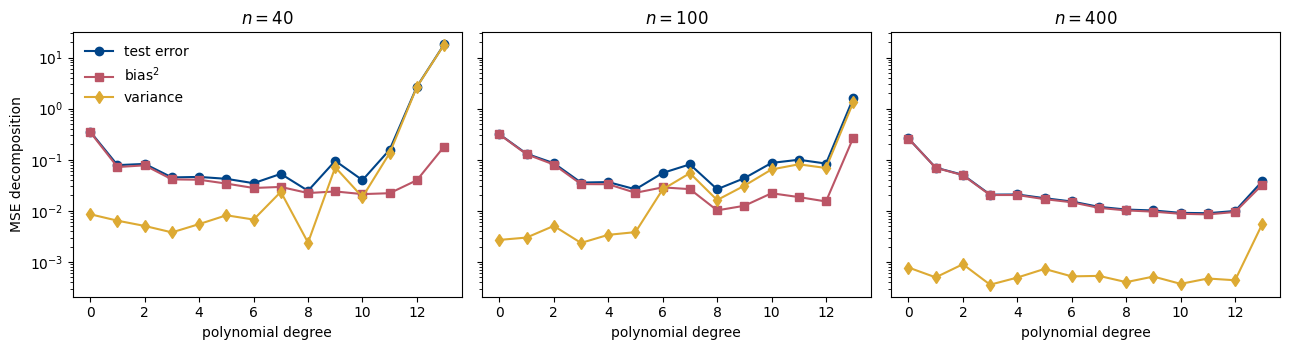

3it [01:43, 34.66s/it]


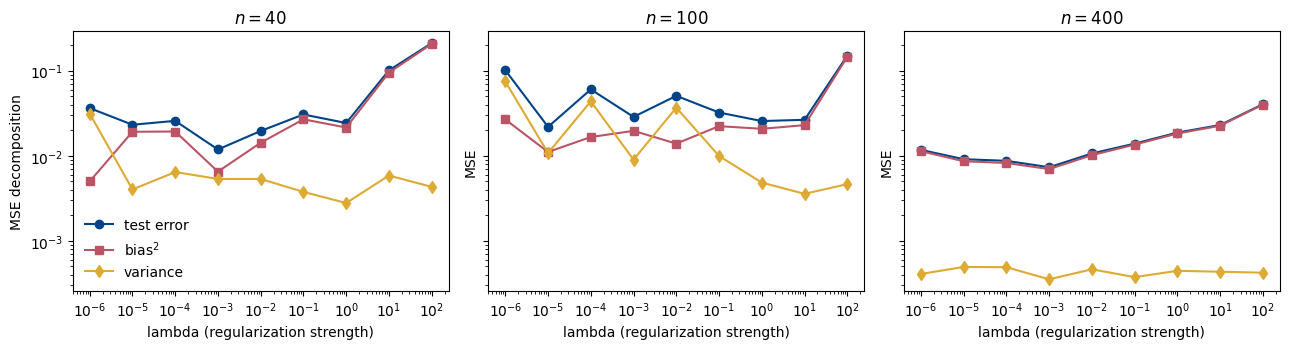

In [10]:
# Your code for exercise 3 here

def bv_sweep(n=40, maxdeg=13, n_bootstraps=100, model='OLS', alpha=None):
    match model:
        case 'OLS':
            pipe = lambda deg: make_pipeline(PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
            if alpha is not None:
                raise Exception("alpha is not used for OLS, ignoring it.")
        case 'Ridge':
            pipe = lambda deg: make_pipeline(PolynomialFeatures(degree=deg), StandardScaler(), Ridge(alpha=alpha))
            if alpha is None:
                raise ValueError("alpha must be specified for Ridge regression.")
        case _:
            raise ValueError(f"Unknown model: {model}")

    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)

    error, bias, variance = np.zeros(maxdeg), np.zeros(maxdeg), np.zeros(maxdeg)
    for degree in range(maxdeg):
        fit_model = pipe(deg=degree)
        y_tilde = np.zeros((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_boot, y_boot = resample(x_train, y_train)
            fit_model.fit(x_boot, y_boot)
            y_tilde[:, i] = fit_model.fit(x_boot, y_boot).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_tilde)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_tilde, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_tilde, axis=1, keepdims=True))

    return error, bias, variance

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
maxdegree = 14
for ax, n_ in tqdm(zip(axes, (40, 100, 400))):
    err, b2, var = bv_sweep(n=n_, maxdeg=maxdegree, n_bootstraps=100)
    ax.plot(range(maxdegree), err, "o-", color=BLUE, label="test error")
    ax.plot(range(maxdegree), b2, "s-", color=RED, label=r"bias$^2$")
    ax.plot(range(maxdegree), var, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
fixeddegree = 12
for ax, n_ in tqdm(zip(axes, (40, 100, 400))):
    alphas = np.logspace(-6, 2, 9)
    err_vs_lambda = []
    b2_vs_lambda = []
    var_vs_lambda = []
    for alpha in alphas:
        err, b2, var = bv_sweep(n=n_, maxdeg=fixeddegree, n_bootstraps=100, model='Ridge', alpha=alpha)
        err_vs_lambda.append(err[-1])
        b2_vs_lambda.append(b2[-1])
        var_vs_lambda.append(var[-1])

    ax.plot(alphas, err_vs_lambda, "o-", color=BLUE, label="test error")
    ax.plot(alphas, b2_vs_lambda, "s-", color=RED, label=r"bias$^2$")
    ax.plot(alphas, var_vs_lambda, "d-", color=YELLOW, label="variance")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("lambda (regularization strength)")
    ax.set_ylabel("MSE")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()




> - for n=40, the first figure succesfully reproduces week36_bias_variance.pdf
> - $n = 40$: 
> - up to a polynomial degree of 4 the model is dominated by the bias $^2$ before the variance takes over and dominates at higher degrees
> - the minimum in the test error is broad and lays between a degree of 5 and 8
> - for higher $n$, the variance decreases and the bias $^2$ dominates over a larger range of degrees, this in turn moves the optimal degree further to higher degrees (especially visible in the $n=400$ case)
> - biasing the regression with $\lambda$ at a fixed degree of 12, lowers the variance with higher lambda, but in turn increases the bias $^2$

## Exercise 4: Cross-validation

Still with the same type of data, we now select models without consuming a
test set.

1. Use scikit-learn's (or perhaps write your own) $k$-fold cross-validation function: shuffle the data,
   split into $k$ folds, use each fold as test set once, and return the mean
   and standard deviation over folds of the test MSE. Do **not** use
   `cross_val_score` inside your own function.
2. Use it with $k = 5$ to compute the CV estimate of the MSE for OLS with
   polynomial degrees $0$ to $13$, and compare with the bootstrap analysis of
   exercise 3: do the two methods point to the same degree window?
3. For a degree-6 polynomial with Ridge regression on
   $y = 3x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$, $n=100$
   (Tuesday's Case 2), compute the CV MSE on
   `np.logspace(-3, 5, 100)` and find the optimal $\lambda$. Any
   scaling/preprocessing must be fitted **inside** each fold — explain in one
   or two sentences why.
4. Try $k = 5, 10$ and $n$ (leave-one-out). Comment on the stability of the
   selected $\lambda$ and on the computational cost.

In [1]:
# Your code for exercise 4 here


def K_fold_mse(x=None, y=None, n=100, k_folds = 5, deg = 6, alphas = np.logspace(-3, 5, 100), seed=2026):
    rng = np.random.default_rng(seed)

    # following block is created by Claude Sonnet 5
    # following prompt was used:
    '''I want to be able to use the same function on data looking like e.g. 

        x = np.linspace(-3, 3, n).reshape(-1, 1)
        y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

        please rewrite the function'''
    
    if x is None or y is None:
        x = rng.standard_normal(n)
        y = 3 * x**2 + rng.standard_normal(n)

    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()   

    folds = KFold(n_splits=k_folds, shuffle=True, random_state=seed)
    polynomial = PolynomialFeatures(degree=deg)

    scores = np.zeros((len(alphas), k_folds))
    for i, alpha in enumerate(alphas):
        for j, (train_idx, test_idx) in enumerate(folds.split(x)):
            xtrain, ytrain = x[train_idx], y[train_idx]
            xtest, ytest = x[test_idx], y[test_idx]

            Xtrain_poly = polynomial.fit_transform(xtrain.reshape(-1, 1))
            Xtest_poly = polynomial.transform(xtest.reshape(-1, 1))
            scaler = StandardScaler().fit(Xtrain_poly)

            ridge = Ridge(alpha=alpha)
            ridge.fit(scaler.transform(Xtrain_poly), ytrain)
            y_tilde = ridge.predict(scaler.transform(Xtest_poly))

            scores[i, j] = np.mean((ytest - y_tilde)**2)

    mse_kfolds = np.mean(scores, axis=1)
    return alphas, mse_kfolds


fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
maxdegree = 15
for ax, n_ in zip(axes, (40, 100, 400)):
    x = np.linspace(-3, 3, n_).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

    mse_kfolds = np.array([K_fold_mse(x=x, y=y, n=n_, k_folds=5, alphas=np.array([0]), deg=deg)[1][0] for deg in range(maxdegree)])
    ax.plot(range(maxdegree), mse_kfolds, "d-", color=YELLOW, label="MSE from K-fold CV")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k_ in tqdm(zip(axes, (5, 10, 100))):
    alphas, mse_kfolds = K_fold_mse(k_folds=k_)
    best = np.argmin(mse_kfolds)
    print(f"k = {k_}: best lambda {alphas[best]:.4g}, cross-validated MSE {mse_kfolds[best]:.4f}")
    
    ax.plot(np.log10(alphas), mse_kfolds, color=BLUE, lw=2, label="own KFold loop")
    ax.plot(np.log10(alphas[best]), mse_kfolds[best], "o", color=YELLOW, ms=9,
        label=rf"minimum: $\lambda\approx{alphas[best]:.3g}$")
    ax.axhline(1.0, color="gray", lw=1, ls=":", label=r"irreducible error $\sigma^2=1$")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\log_{10}\lambda$")
axes[0].set_ylabel("cross-validated MSE")
axes[0].legend(frameon=False)
plt.show()








n = 100
x = rng.uniform(-2.0, 2.0, n)
y = 2.0 - x + 5.0 * x**2 + 0.5 * rng.standard_normal(n)

alphas, mse_kfolds = K_fold_mse(x=x, y=y, n=n, k_folds=k_, alphas=np.logspace(-5, 2, 20), deg=2)
best = np.argmin(mse_kfolds)
print(f"k = {k_}: best lambda {alphas[best]:.4g}, cross-validated MSE {mse_kfolds[best]:.4f}")

NameError: name 'np' is not defined

> - for $n=40$, the MSE behaviour qualitatively reproduces the behaviour of the test error as in the bootstrap analysis and also points to the same optimal window
> - however, for higher $n$ the cross-validation method does not show the overfitting behaviour at high orders of polynomial degree, especially for $n=100$
> - this happens, due to effective shrinkage of the training sample size in the bootstrap method, while the cross-validation method tries to preserve all available data
> - any scaling/preprocessing process has to happen inside each fold to properly differentiate between training data and test data in each k-step, otherwise the training-data is scaled wrong
> - the optimal lambda is calculated using np.argmin and printed: 
>
>|k|best $\lambda$ | cross-validatedd MSE|
>|---|---|---|
>|5| 1.177| 1.4569|
>|10| 2.057| 1.4708|
>|100| 2.477| 1.4435|
>
> - for increasing $k$, the optimal lambda goes from 1.177 to 2.477, with more folds and therefor more data per fit, we expect the variance to decrease and to have a larger impact of the bias, we expect the lambda to shift
> - increasing $k$ also increases the needed computational effort, as the algorithm has to beform the fit and cost evaluation k times (also compare to the tqdm output for the needed time for each $k$)

## Exercise 5 (optional): error bars from the bootstrap

Use the bootstrap to attach uncertainties to fitted parameters, where the
analytical formula of exercise 1 can be checked — and where it cannot.

1. For OLS on a degree-3 polynomial fit of the exercise-3 data, bootstrap the
   training data 1000 times and histogram the resulting
   $\hat{\theta}_j^*$. Compare the bootstrap standard deviations with the
   analytical standard errors
   $\hat{\sigma}\sqrt{[(\boldsymbol{X}^T\boldsymbol{X})^{-1}]_{jj}}$ of
   Eq. (2.48).
2. Repeat for Lasso with a small penalty. Why is the bootstrap now the only
   option on the table? (Which assumption behind Eq. (2.48) fails?)

In [ ]:
# Your code for exercise 5 here

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 4 at midnight**. Collaboration is encouraged — list
your collaborators.